In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

In [87]:
data_df = pd.read_csv('C:\\Users\\Shankar\\Desktop\\customer data set hugging face\\customer_support_tickets.csv')
data_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [88]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [89]:
for column in data_df.columns:
    print(f"{column}: {data_df[column].isnull().sum()} null values")

Ticket ID: 0 null values
Customer Name: 0 null values
Customer Email: 0 null values
Customer Age: 0 null values
Customer Gender: 0 null values
Product Purchased: 0 null values
Date of Purchase: 0 null values
Ticket Type: 0 null values
Ticket Subject: 0 null values
Ticket Description: 0 null values
Ticket Status: 0 null values
Resolution: 5700 null values
Ticket Priority: 0 null values
Ticket Channel: 0 null values
First Response Time: 2819 null values
Time to Resolution: 5700 null values
Customer Satisfaction Rating: 5700 null values


## Univariant Analysis

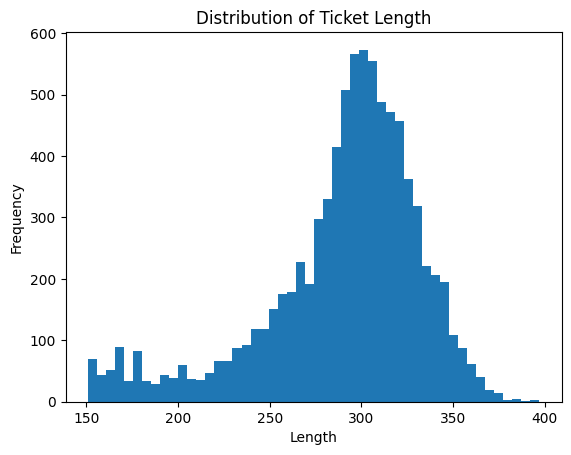

In [90]:
data_df['text_length'] = data_df['Ticket Description'].astype(str).apply(len)

plt.hist(data_df['text_length'], bins=50)
plt.title("Distribution of Ticket Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

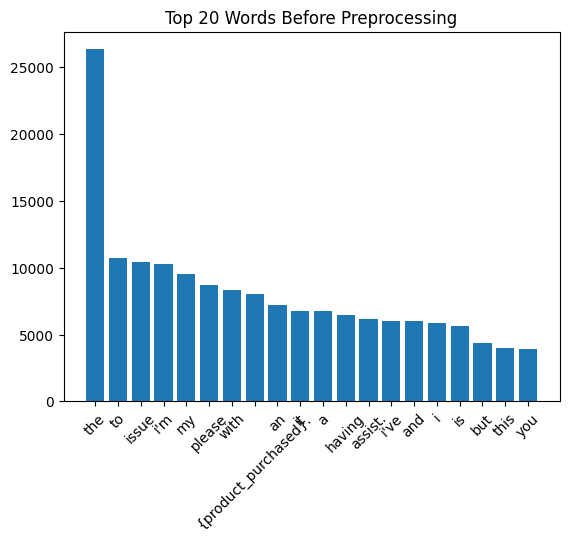

In [91]:
text_data = data_df['Ticket Description'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words Before Preprocessing")
plt.show()

In [92]:
unique_words = set(all_words)
print("Vocabulary size:", len(unique_words))

Vocabulary size: 13826


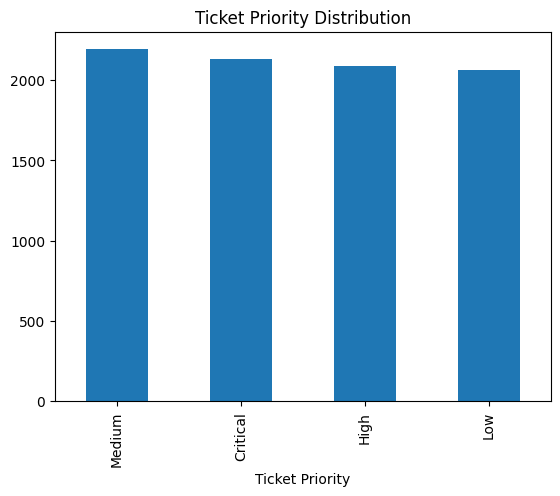

In [93]:
data_df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.show()

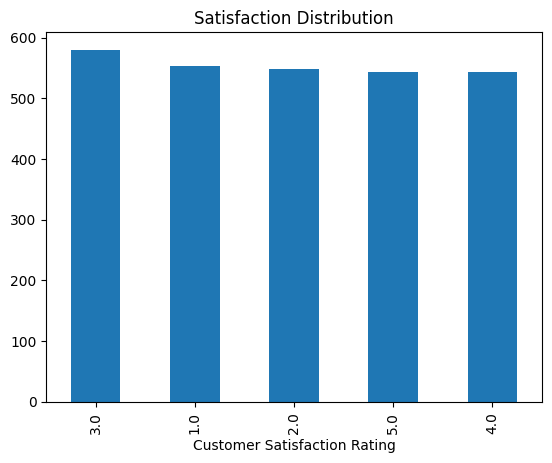

In [94]:
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='bar')
plt.title("Satisfaction Distribution")
plt.show()

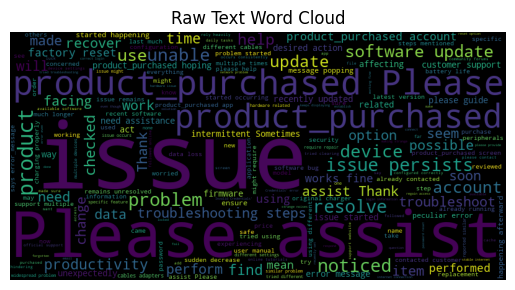

In [95]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(text_data))

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Raw Text Word Cloud")
plt.show()

## Bivariate Analysis

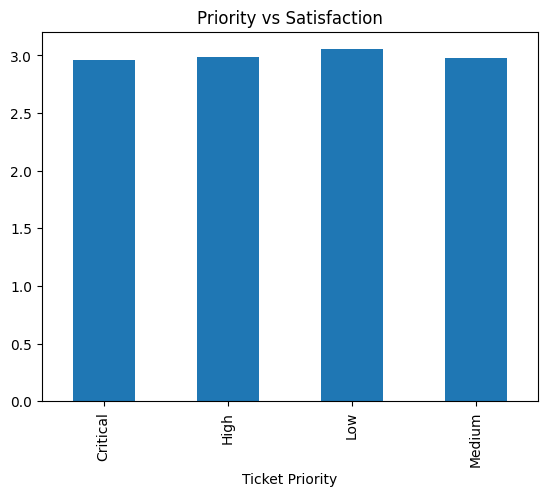

In [96]:
data_df.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Priority vs Satisfaction")
plt.show()

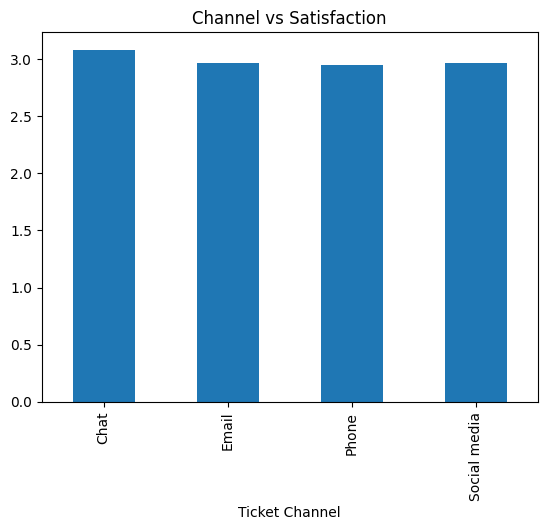

In [97]:
data_df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Channel vs Satisfaction")
plt.show()

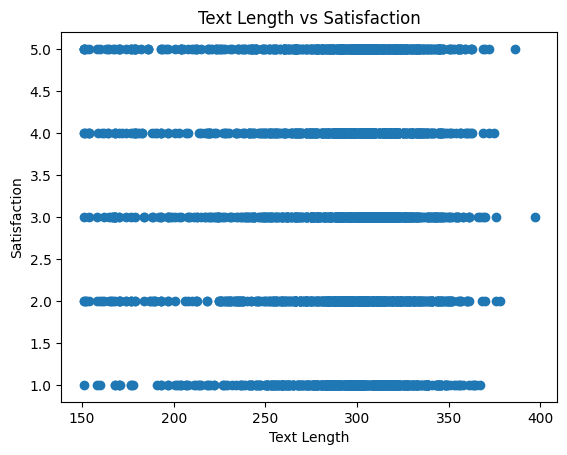

In [98]:
plt.scatter(data_df['text_length'], data_df['Customer Satisfaction Rating'])
plt.xlabel("Text Length")
plt.ylabel("Satisfaction")
plt.title("Text Length vs Satisfaction")
plt.show()

## Multivariant Analysis

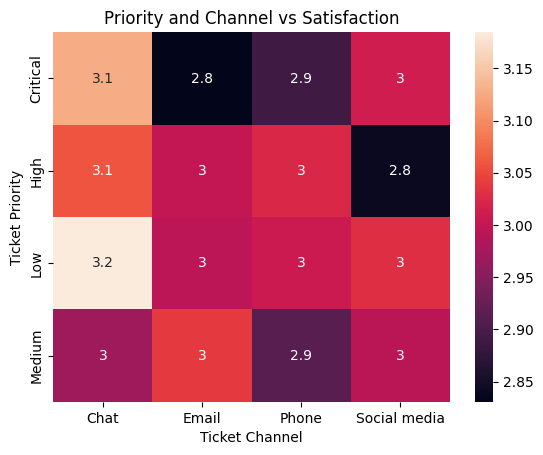

In [99]:
pivot = data_df.pivot_table(values='Customer Satisfaction Rating',index='Ticket Priority',columns='Ticket Channel',aggfunc='mean')
sns.heatmap(pivot, annot=True)
plt.title("Priority and Channel vs Satisfaction")
plt.show()

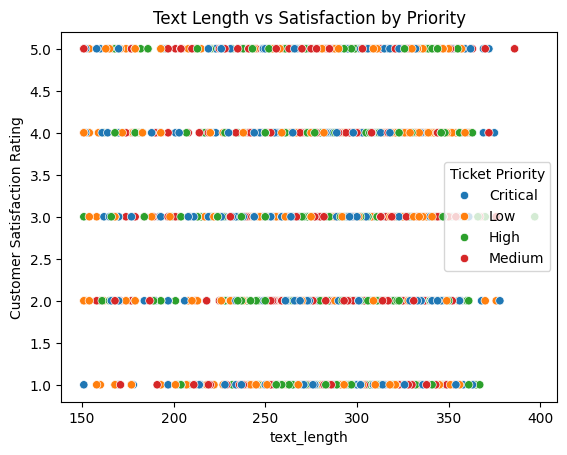

In [100]:
sns.scatterplot(data=data_df,x='text_length',y='Customer Satisfaction Rating',hue='Ticket Priority')
plt.title("Text Length vs Satisfaction by Priority")
plt.show()

## Preprocessing

In [101]:
data_df['text'] = data_df['Ticket Subject'].fillna('') + " " + data_df['Ticket Description'].fillna('')

In [102]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    product setup  having  issue with the productp...
1    peripheral compatibility  having  issue with t...
2    network problem  facing  problem with  product...
3    account access  having  issue with the product...
4    data loss  having  issue with the productpurch...
Name: clean_text, dtype: str

In [103]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# removing the words from the word cloud which i did above
#custom_words = {'please', 'help', 'issue', 'product', 'customer'}
custom_words = {
    'please', 'help', 'issue', 'problem', 'product', 'customer',
    'ive', 'im', 'would', 'could', 'also',
    'productpurchased', 'assist', 'support',
    'tried', 'trying', 'check', 'checked',
    'need', 'want', 'hoping', 'perform',
    'already', 'multiple', 'time','contacted', 'performed', 'started', 'happening',
    'using', 'use', 'work', 'working', 'didnt', 'did',
    'get', 'getting', 'make', 'made'
}

def preprocess(text):
    tokens = word_tokenize(text)
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and word not in custom_words and len(word) > 2
    ]
    
    return " ".join(tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [104]:
data_df[['text', 'processed_text']].head(5)

,text,processed_text
0,Product setup I'm having an issue with the {pr...,setup billing zip code appreciate requested we...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility change existing facin...
2,Network problem I'm facing a problem with my {...,network facing turning fine yesterday doesnt r...
3,Account access I'm having an issue with the {p...,account access youre interested love see happe...
4,Data loss I'm having an issue with the {produc...,data loss note seller responsible damage arisi...


### TFIDF

In [105]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2))

X = tfidf.fit_transform(data_df['processed_text'])

In [106]:
X.shape

(8469, 1000)

In [107]:
x_df = pd.DataFrame(X.toarray())
print(x_df.head())

   0    1         2    3    4    5    6    7    8         9    ...  990  991  \
0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  ...  0.0  0.0   
1  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  ...  0.0  0.0   
2  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  ...  0.0  0.0   
3  0.0  0.0  0.209838  0.0  0.0  0.0  0.0  0.0  0.0  0.179678  ...  0.0  0.0   
4  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  0.0  0.0  0.000000  ...  0.0  0.0   

        992       993  994  995  996       997  998  999  
0  0.000000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  
1  0.000000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  
2  0.219265  0.220014  0.0  0.0  0.0  0.000000  0.0  0.0  
3  0.000000  0.000000  0.0  0.0  0.0  0.292088  0.0  0.0  
4  0.000000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  

[5 rows x 1000 columns]


### Embeddings

In [108]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [109]:
embeddings = model.encode(data_df['processed_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

In [110]:
embeddings.shape

(8469, 384)

In [111]:
embedding_df = pd.DataFrame(embeddings)
print(embedding_df.head())

        0         1         2         3         4         5         6    \
0 -0.060726  0.027775  0.030571  0.011972 -0.021676 -0.052124 -0.005648   
1  0.012924 -0.112255  0.083540  0.000467  0.028988 -0.079410 -0.023085   
2 -0.032761  0.086672  0.076674  0.100858  0.037201 -0.080115 -0.093048   
3 -0.057591 -0.074447  0.021754  0.058790  0.034984  0.016333  0.027493   
4 -0.053837  0.126504  0.038507 -0.054796  0.017199  0.007257  0.043782   

        7         8         9    ...       374       375       376       377  \
0 -0.055030 -0.033866  0.009081  ...  0.051726 -0.048498 -0.048653  0.001713   
1 -0.031125 -0.024042 -0.003763  ...  0.012454 -0.074859 -0.047401 -0.002404   
2 -0.031406 -0.001198 -0.045561  ... -0.010738 -0.061180 -0.040824  0.007967   
3 -0.002868  0.103969 -0.002415  ... -0.007958  0.035230  0.057386 -0.027371   
4  0.084358  0.029288  0.138905  ... -0.003482 -0.002998  0.009818  0.053226   

        378       379       380       381       382       383  
0  0

## Model

### Kmeans

#### TFIDF

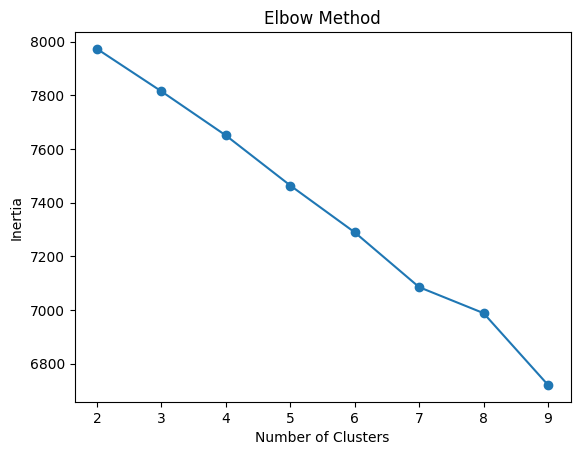

In [112]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [113]:
k = 7

kmeans = KMeans(n_clusters=k, random_state=42)
data_df['cluster'] = kmeans.fit_predict(X)

In [114]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=10):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeans, X)


Cluster 0:
['sometimes', 'act', 'time act', 'act unexpectedly', 'facing intermittent', 'intermittent sometimes', 'sometimes work', 'unexpectedly', 'fine time', 'intermittent']

Cluster 1:
['unresolved', 'time remains', 'factory', 'factory reset', 'reset resolve', 'reset', 'troubleshooting step', 'troubleshooting', 'persists', 'resolve']

Cluster 2:
['screen say', 'errormessage mean', 'say errormessage', 'errormessage', 'popping', 'peculiar', 'peculiar error', 'popping screen', 'noticed peculiar', 'message popping']

Cluster 3:
['heavily', 'possible', 'soon', 'assistance', 'soon possible', 'affecting', 'affecting productivity', 'possible affecting', 'assistance soon', 'productivity']

Cluster 4:
['like', 'ensure', 'security', 'safe', 'data safe', 'concerned', 'like ensure', 'concerned security', 'ensure data', 'security like']

Cluster 5:
['afterward related', 'afterward', 'firmware afterward', 'related update', 'firmware', 'updated', 'related', 'software', 'software update', 'update']

In [115]:
sil_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    sil_scores.append(score)

    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.0221
k=3, Silhouette Score=0.0314
k=4, Silhouette Score=0.0423
k=5, Silhouette Score=0.0541
k=6, Silhouette Score=0.0662
k=7, Silhouette Score=0.0790
k=8, Silhouette Score=0.0830
k=9, Silhouette Score=0.1007


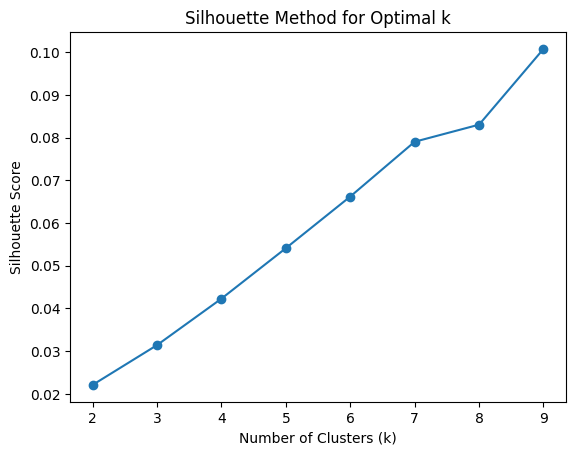

In [135]:
plt.plot(k_values, sil_scores,  marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [116]:
k = 9

kmeans = KMeans(n_clusters=k, random_state=42)
data_df['cluster'] = kmeans.fit_predict(X)

In [117]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=10):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeans, X)


Cluster 0:
['widespread', 'experiencing device', 'experiencing', 'sure', 'resolve', 'device', 'reset', 'factory', 'factory reset', 'reset resolve']

Cluster 1:
['screen say', 'errormessage mean', 'say errormessage', 'errormessage', 'popping', 'peculiar', 'peculiar error', 'popping screen', 'noticed peculiar', 'message popping']

Cluster 2:
['action', 'guide', 'find', 'desired', 'guide step', 'unable find', 'desired action', 'action guide', 'option desired', 'find option']

Cluster 3:
['like', 'ensure', 'security', 'safe', 'data safe', 'concerned', 'like ensure', 'concerned security', 'ensure data', 'security like']

Cluster 4:
['user', 'mentioned', 'manual', 'step mentioned', 'user manual', 'manual persists', 'mentioned user', 'step', 'troubleshooting', 'troubleshooting step']

Cluster 5:
['noticed', 'change', 'havent', 'recent', 'occurring', 'havent change', 'recent software', 'occurring recent', 'update havent', 'change device']

Cluster 6:
['sometimes', 'fine time', 'act', 'act une

### Embeddings

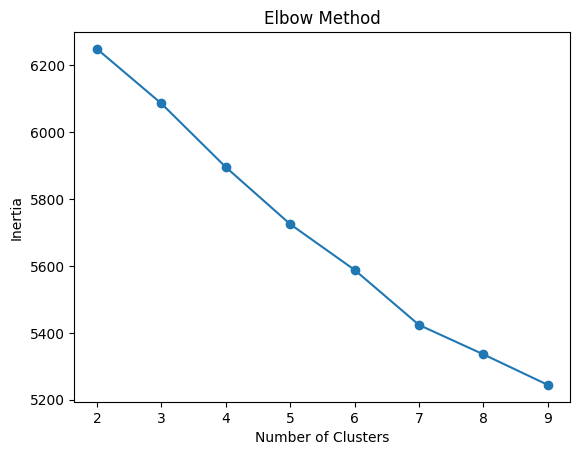

In [118]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(embeddings)
    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [121]:
k = 5

kmeans_embed = KMeans(n_clusters=k, random_state=42)
data_df['cluster_embed'] = kmeans_embed.fit_predict(embeddings)

In [122]:
for i in range(k):
    print(f"\nCluster {i}:")
    print(data_df[data_df['cluster_embed'] == i]['processed_text'].head(5).tolist())


Cluster 0:
['network facing turning fine yesterday doesnt respond really original charger came charging properly', 'setup recently set fails connect available network step take troubleshoot cant find productip field concerned security like ensure data safe', 'recommendation recently set fails connect available network step take troubleshoot know answer let know noticed sudden decrease battery life used last much longer', 'installation recently set fails connect available network step take troubleshoot next step resolve user noticed occurs consistently specific feature application', 'network dont dont see contact unable find option desired action guide step']

Cluster 1:
['setup billing zip code appreciate requested website address double email address troubleshooting step mentioned user manual persists', 'account access youre interested love see happen feedback time remains unresolved', 'payment facing turning fine yesterday doesnt respond remove new productpurch available software up

### HAC

In [124]:
X_dense = X.toarray()

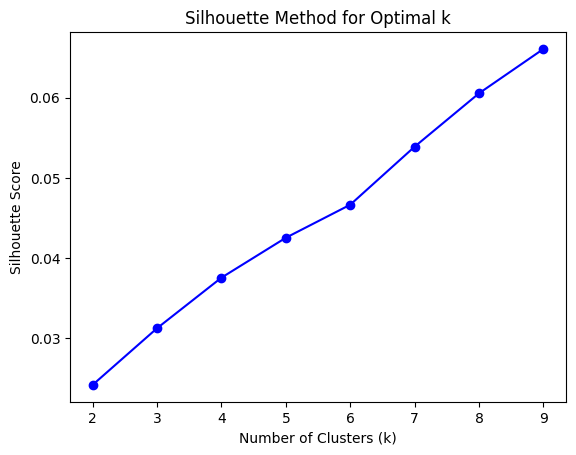

In [126]:
scores = []
k_range = range(2, 10) # Silhouette requires at least 2 clusters

for k in k_range:
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels)
    scores.append(score)

plt.plot(k_range, scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [127]:
hac_tfidf = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

data_df['cluster_hac_tfidf'] = hac_tfidf.fit_predict(X_dense)

In [128]:
for i in range(5):
    print(f"\nCluster {i}:")
    
    indices = np.where(data_df['cluster_hac_tfidf'] == i)[0]
    cluster_tfidf = X[indices].mean(axis=0)
    
    top_indices = np.argsort(cluster_tfidf.A1)[-20:][::-1]
    terms = tfidf.get_feature_names_out()
    
    print([terms[j] for j in top_indices])


Cluster 0:
['software', 'update', 'account', 'device', 'data', 'persists', 'resolve', 'network', 'software update', 'step', 'request', 'compatibility', 'reset', 'productivity', 'bug', 'hardware', 'available', 'might', 'troubleshooting', 'troubleshooting step']

Cluster 1:
['intermittent sometimes', 'unexpectedly', 'intermittent', 'facing intermittent', 'time act', 'sometimes work', 'act unexpectedly', 'act', 'fine time', 'sometimes', 'work fine', 'work', 'facing', 'fine', 'time', 'request', 'compatibility', 'hardware', 'item', 'account']

Cluster 2:
['peculiar', 'peculiar error', 'popping', 'popping screen', 'say errormessage', 'errormessage', 'noticed peculiar', 'errormessage mean', 'message popping', 'screen say', 'error message', 'mean', 'message', 'screen', 'say', 'error', 'noticed', 'request', 'compatibility', 'refund']

Cluster 3:
['concerned', 'concerned security', 'like ensure', 'ensure data', 'security like', 'data safe', 'safe', 'security', 'ensure', 'like', 'data', 'account

In [129]:
hac_embed = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

data_df['cluster_hac_embed'] = hac_embed.fit_predict(embeddings)

In [132]:
for i in range(5):
    print(f"\nCluster {i}:")
    
    cluster_indices = np.where(data_df['cluster_hac_embed'] == i)[0]
    cluster_embeddings = embeddings[cluster_indices]
    
    centroid = cluster_embeddings.mean(axis=0)
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    closest = cluster_indices[np.argsort(distances)[:5]]
    
    for idx in closest:
        print("-", data_df['text'].iloc[idx])


Cluster 0:
- Product compatibility I'm having an issue with the {product_purchased}. Please assist.

I'm having an issue with the "The purchase will be cancelled if the product is not purchased yet". Please assist. (2 hours)

I This problem started occurring after the recent software update. I haven't made any other changes to the device.
- Payment issue I'm having an issue with the {product_purchased}. Please assist.

Thank you for any support you can provide, we've been in contact with the seller. This problem started occurring after the recent software update. I haven't made any other changes to the device.
- Peripheral compatibility I'm having an issue with the {product_purchased}. Please assist. This is an Error, I guess, especially since there has not been a single successful refund after the last three days.


Thanks!

-K I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.
- Software bug I'm having an issue with the {product